# **1. 그래프의 상태 업데이트**

* HumanMessage : 사용자(사람)의 메시지
* AIMessage : AI(LLM)의 메시지
* AnyMessage : HumanMessage, AIMessage를 포함하는 메시지

In [1]:
!pip install langgraph

### 1. 디셔너리 타입 vs TypedDict

```
- 디셔너리 타입
state = {
    "messages": [],
    "step": 1
}

- TypedDict
{
    "messages": list
    "step": int
}
```



### 2. 랭그래프에서 TypedDict을 사용하는 이유
- 랭그래프에서는 State Graph라는 개념이 있음
```
노드 + 노드 + 노드
```
- state가 계속 전달됨
```
# State에는 messages라는 key가 있고 값은 AnyMessage 리스트다
class state(TypedDict):
    messages: list[AnyMessage]
```

In [2]:
from langchain_core.messages import AnyMessage
from typing_extensions import TypedDict

class State(TypedDict):
    messages: list[AnyMessage]
    extra_field: int

In [3]:
from langchain_core.messages import AIMessage

def node(state: State):
    messages = state['messages']
    new_message = AIMessage("안녕하세요! 무엇을 도와드릴까요?")
    # extra_field: 일반 속성을 더함
    return {"messages": messages + [new_message], "extra_field": 10}

In [4]:
from langgraph.graph import StateGraph

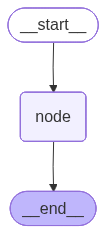

In [5]:
# StateGraph: LangGraph에서 사용하는 상태 기반 그래프
graph_builder = StateGraph(State)
graph_builder.add_node("node", node)
# set_entry_point: 그래프의 시작 노드를 지정하는 엣지(Start -> "node")
graph_builder.set_entry_point("node")
graph = graph_builder.compile()

graph

In [6]:
from langchain_core.messages import HumanMessage

In [7]:
result = graph.invoke({"messages": [HumanMessage("안녕")]})
result

{'messages': [HumanMessage(content='안녕', additional_kwargs={}, response_metadata={}),
  AIMessage(content='안녕하세요! 무엇을 도와드릴까요?', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])],
 'extra_field': 10}

In [8]:
result['messages']

[HumanMessage(content='안녕', additional_kwargs={}, response_metadata={}),
 AIMessage(content='안녕하세요! 무엇을 도와드릴까요?', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])]

# **2. 대화메시지 상태 누적 업데이트**
[add_messages](https://reference.langchain.com/python/langgraph/graph/message/add_messages) 는 기존 메시지에서 추가 메시지를 병합하는 데 사용하는 함수로, 새로 들어온 메시지를 추가할 때 사용할 수 있는 리듀서 역할

In [9]:
from typing_extensions import Annotated
from langgraph.graph.message import add_messages

In [10]:
class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    extra_field: int

In [11]:
def node(state: State):
    messages = state['messages']
    new_message = AIMessage("안녕하세요! 무엇을 도와드릴까요?")
    return {"messages": new_message, "extra_field": 10}

In [12]:
from langgraph.graph import StateGraph

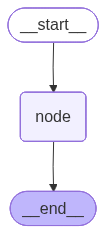

In [13]:
graph_builder = StateGraph(State)
graph_builder.add_node("node", node)
graph_builder.set_entry_point("node")
graph = graph_builder.compile()

graph

In [14]:
# role 종류
# user: 사용자 메시지
# assistant: AI 메시지
# system: 시스템 지시
# tool: 도구 결과
input_message = {"role":"user", "content":"안녕하세요"}
# invoke: 그래프 실행 함수
result = graph.invoke({"messages": [input_message]})

for message in result['messages']:
    message.pretty_print()

================================ Human Message =================================

안녕하세요
================================== Ai Message ==================================

안녕하세요! 무엇을 도와드릴까요?


In [15]:
result['messages']

[HumanMessage(content='안녕하세요', additional_kwargs={}, response_metadata={}, id='8ee4bc4b-c4a3-4b89-a0f1-457e98cd8c27'),
 AIMessage(content='안녕하세요! 무엇을 도와드릴까요?', additional_kwargs={}, response_metadata={}, id='20b24487-db7c-4b4b-9c6f-80f28ae0cb43', tool_calls=[], invalid_tool_calls=[])]

* ainvoke: 비동기 처리로 여러 요청을 동시에 보낼 수 있음
```
await graph.ainvoke({"messages": [input_message]})
```

* stream: 중간 결과를 실시간으로 반환함
    - stream_mode="values" 각 단계의 현재 상태 값 출력
    - Default) stream_mode="updates" 각 단계의 상태 업데이트만 출력
    - stream_mode="messages" 각 단계의 메시지 출력

In [16]:
for chunk in graph.stream({"messages": [input_message]}, stream_mode='values'):
    print(chunk)
    for state_key, state_value in chunk.items():
        if state_key == "messages":
            state_value[-1].pretty_print()

{'messages': [HumanMessage(content='안녕하세요', additional_kwargs={}, response_metadata={}, id='15e9ca0b-7731-404b-b650-bfbde14f8768')]}
================================ Human Message =================================

안녕하세요
{'messages': [HumanMessage(content='안녕하세요', additional_kwargs={}, response_metadata={}, id='15e9ca0b-7731-404b-b650-bfbde14f8768'), AIMessage(content='안녕하세요! 무엇을 도와드릴까요?', additional_kwargs={}, response_metadata={}, id='bfbd6ccc-2751-4a40-a9e9-2691654ca7f0', tool_calls=[], invalid_tool_calls=[])], 'extra_field': 10}
================================== Ai Message ==================================

안녕하세요! 무엇을 도와드릴까요?


In [17]:
for chunk in graph.stream({"messages": [input_message]}, stream_mode="updates"):
    print(chunk)
    for node, value in chunk.items():
        if node:
            print(node)
        if "messages" in value:
            print(value['messages'].content)

{'node': {'messages': AIMessage(content='안녕하세요! 무엇을 도와드릴까요?', additional_kwargs={}, response_metadata={}, id='8040f7aa-7be5-47d3-a8ae-68d251bb6ed3', tool_calls=[], invalid_tool_calls=[]), 'extra_field': 10}}
node
안녕하세요! 무엇을 도와드릴까요?


In [18]:
for chunk_msg, metadata in graph.stream({"messages": [input_message]}, stream_mode="messages"):
    print(chunk_msg)
    print(chunk_msg.content)
    print(metadata)
    print(metadata["langgraph_node"])

content='안녕하세요! 무엇을 도와드릴까요?' additional_kwargs={} response_metadata={} id='7203eb67-b79a-438c-9f4f-796b4f8792c1' tool_calls=[] invalid_tool_calls=[]
안녕하세요! 무엇을 도와드릴까요?
{'langgraph_step': 1, 'langgraph_node': 'node', 'langgraph_triggers': ('branch:to:node',), 'langgraph_path': ('__pregel_pull', 'node'), 'langgraph_checkpoint_ns': 'node:d1513d2a-9739-9138-8417-eb539fde5be1'}
node


In [19]:
async for chunk_msg, metadata in graph.astream({"messages": [input_message]}, stream_mode="messages"):
    print(chunk_msg)
    print(chunk_msg.content)
    print(metadata)
    print(metadata["langgraph_node"])

content='안녕하세요! 무엇을 도와드릴까요?' additional_kwargs={} response_metadata={} id='44b0ece9-fd04-45ce-aac3-1e003b462137' tool_calls=[] invalid_tool_calls=[]
안녕하세요! 무엇을 도와드릴까요?
{'langgraph_step': 1, 'langgraph_node': 'node', 'langgraph_triggers': ('branch:to:node',), 'langgraph_path': ('__pregel_pull', 'node'), 'langgraph_checkpoint_ns': 'node:86f63526-d67d-1cf7-e897-a2035e338bb1'}
node


# **3. 노드와 엣지 연결**

In [20]:
from typing_extensions import TypedDict

In [21]:
class State(TypedDict):
    value_1: str
    value_2: int

In [22]:
def step_1(state: State):
    return {"value_1": state['value_1']}

def step_2(state: State):
    current_value_1 = state['value_1']
    return {"value_1": f'{current_value_1} b'}

def step_3(state: State):
    return {"value_2": 10}

In [23]:
from langgraph.graph import START, StateGraph

In [24]:
graph_builder = StateGraph(State)

graph_builder.add_node(step_1)
graph_builder.add_node(step_2)
graph_builder.add_node(step_3)

graph_builder.add_edge(START, 'step_1')
graph_builder.add_edge('step_1', 'step_2')
graph_builder.add_edge('step_2', 'step_3')

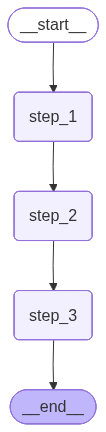

In [25]:
graph = graph_builder.compile()
graph

# **4. 노드와 엣지를 한번에 연결**

In [26]:
# add_sequnce: 노드를 순서대로 연결하는 함수
graph_builder = StateGraph(State).add_sequence([step_1, step_2, step_3])
graph_builder.add_edge(START, "step_1")
graph = graph_builder.compile()

graph.invoke({"value_1": "c"})

{'value_1': 'c b', 'value_2': 10}

# **5. 병렬로 연결**

<img src='https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2FbKsmXN%2FbtsQoa6BiQH%2FAAAAAAAAAAAAAAAAAAAAAPpgPBweh6r0kpol4tFqhOR7MdAaIfiH-Lj4HXxoNYBU%2Fimg.png%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1774969199%26allow_ip%3D%26allow_referer%3D%26signature%3Det57M4W%252B1rxuWT1yQVw6r0BDHw4%253D'>

In [27]:
import operator
from typing import Annotated, Any
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

In [28]:
class State(TypedDict):
    aggregate: Annotated[list, operator.add]

In [29]:
def a(state: State):
    print(f'Adding "A" to {state["aggregate"]}')
    return {"aggregate": ['A']}

def b(state: State):
    print(f'Adding "B" to {state["aggregate"]}')
    return {"aggregate": ['B']}

def c(state: State):
    print(f'Adding "C" to {state["aggregate"]}')
    return {"aggregate": ['C']}

def d(state: State):
    print(f'Adding "D" to {state["aggregate"]}')
    return {"aggregate": ['D']}

In [30]:
graph_builder = StateGraph(State)

graph_builder.add_node(a)
graph_builder.add_node(b)
graph_builder.add_node(c)
graph_builder.add_node(d)

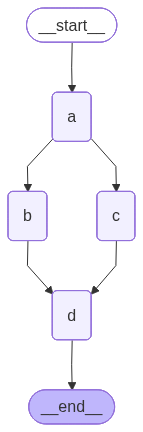

In [31]:
graph_builder.add_edge(START, "a")
graph_builder.add_edge("a", "b")
graph_builder.add_edge("a", "c")
graph_builder.add_edge("b", "d")
graph_builder.add_edge("c", "d")
graph_builder.add_edge("d", END)
graph = graph_builder.compile()

graph

In [32]:
graph.invoke({"aggregate":[]})

Adding "A" to []
Adding "B" to ['A']
Adding "C" to ['A']
Adding "D" to ['A', 'B', 'C']


{'aggregate': ['A', 'B', 'C', 'D']}

# **6. 조건부 엣지 병렬 연결**
<img src='https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2FIHeX1%2FbtsQqoQbMcg%2FAAAAAAAAAAAAAAAAAAAAAI-WYn3hoGJZH0YGGZUAjDY2Xcsn6rtN7Qei9VUmGo2X%2Fimg.png%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1774969199%26allow_ip%3D%26allow_referer%3D%26signature%3D2379LDy77wPIiHWUYKLbs2LPZvQ%253D'>

In [33]:
import operator
from typing import Annotated, Sequence
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

In [34]:
class State(TypedDict):
    aggregate: Annotated[list, operator.add]
    which: str

In [35]:
def a(state: State):
    print(f'Adding "A" to {state["aggregate"]}')
    return {"aggregate": ["A"]}

def b(state: State):
    print(f'Adding "B" to {state["aggregate"]}')
    return {"aggregate": ["B"]}

def c(state: State):
    print(f'Adding "C" to {state["aggregate"]}')
    return {"aggregate": ["C"]}

def d(state: State):
    print(f'Adding "D" to {state["aggregate"]}')
    return {"aggregate": ["D"]}

def e(state: State):
    print(f'Adding "E" to {state["aggregate"]}')
    return {"aggregate": ["E"]}

In [36]:
graph_builder = StateGraph(State)
graph_builder.add_node(a)
graph_builder.add_node(b)
graph_builder.add_node(c)
graph_builder.add_node(d)
graph_builder.add_node(e)
graph_builder.add_edge(START, "a")

In [37]:
def route_bc_or_cd(state: State) -> Sequence[str]:
    if state['which'] == 'cd':
        return ['c', 'd']
    return ['b', 'c']

intermediates = ['b', 'c', 'd']
# add_conditional_edges: 노드 다음에 실행할 노드를 조건 함수로 결정
graph_builder.add_conditional_edges(
    "a", route_bc_or_cd, intermediates
)

In [38]:
for node in intermediates:
    graph_builder.add_edge(node, 'e')

graph_builder.add_edge("e", END)
graph = graph_builder.compile()
graph

ValueError: Failed to reach https://mermaid.ink API while trying to render your graph. Status code: 503.

To resolve this issue:
1. Check your internet connection and try again
2. Try with higher retry settings: `draw_mermaid_png(..., max_retries=5, retry_delay=2.0)`
3. Use the Pyppeteer rendering method which will render your graph locally in a browser: `draw_mermaid_png(..., draw_method=MermaidDrawMethod.PYPPETEER)`

In [39]:
graph.invoke({"aggregate": [], "which": "bc"})

Adding "A" to []
Adding "B" to ['A']
Adding "C" to ['A']
Adding "E" to ['A', 'B', 'C']


{'aggregate': ['A', 'B', 'C', 'E'], 'which': 'bc'}

In [40]:
graph.invoke({"aggregate": [], "which": "cd"})

Adding "A" to []
Adding "C" to ['A']
Adding "D" to ['A']
Adding "E" to ['A', 'C', 'D']


{'aggregate': ['A', 'C', 'D', 'E'], 'which': 'cd'}

# **7. 조건과 반복**

<img src='https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2FexNpm9%2FbtsQqoil95F%2FAAAAAAAAAAAAAAAAAAAAAIPncRoH-KNiTSy0fHLkuCYoGImVqZSYLqCJFGTP-wrG%2Fimg.png%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1774969199%26allow_ip%3D%26allow_referer%3D%26signature%3D7XPcTIf3uYOEuTyJu5Y2j40yDEk%253D'>

In [41]:
import operator
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

In [42]:
class State(TypedDict):
    aggregate: Annotated[list, operator.add]

In [43]:
def a(state: State):
    print(f'Node A 처리 중 현재 상태값 : {state["aggregate"]}')
    return {"aggregate": ["A"]}


def b(state: State):
    print(f'Node B 처리 중 현재 상태값 : {state["aggregate"]}')
    return {"aggregate": ["B"]}


graph_builder = StateGraph(State)
graph_builder.add_node(a)
graph_builder.add_node(b)

In [44]:
def route(state: State):
    if len(state['aggregate']) < 7:
        return "b"
    else:
        return END

In [45]:
graph_builder.add_edge(START, "a")
graph_builder.add_conditional_edges("a", route)
graph_builder.add_edge("b", "a")
graph = graph_builder.compile()

In [46]:
import requests, zlib, base64
from IPython.display import Image

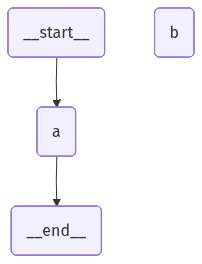

In [47]:
code = graph.get_graph().draw_mermaid()
encoded = base64.urlsafe_b64encode(zlib.compress(code.encode())).decode()
url = f"https://kroki.io/mermaid/png/{encoded}"
resp = requests.get(url)
display(Image(resp.content))

In [48]:
graph.invoke({'aggregate': []})

Node A 처리 중 현재 상태값 : []
Node B 처리 중 현재 상태값 : ['A']
Node A 처리 중 현재 상태값 : ['A', 'B']
Node B 처리 중 현재 상태값 : ['A', 'B', 'A']
Node A 처리 중 현재 상태값 : ['A', 'B', 'A', 'B']
Node B 처리 중 현재 상태값 : ['A', 'B', 'A', 'B', 'A']
Node A 처리 중 현재 상태값 : ['A', 'B', 'A', 'B', 'A', 'B']


{'aggregate': ['A', 'B', 'A', 'B', 'A', 'B', 'A']}

In [49]:
from langgraph.errors import GraphRecursionError
# GraphRecursionError 로 에러를 반환하는 방법
try:
    graph.invoke({"aggregate": []}, config={"recursion_limit": 4})
except GraphRecursionError: # 반복 종료 조건에 도달할 수 없는 경우
    print("Recursion Error")

Node A 처리 중 현재 상태값 : []
Node B 처리 중 현재 상태값 : ['A']
Node A 처리 중 현재 상태값 : ['A', 'B']
Node B 처리 중 현재 상태값 : ['A', 'B', 'A']
Recursion Error
